# Task 1 — Exploratory Data Analysis and Preprocessing

**Goal:** Understand the raw CFPB complaint data, filter to the four required product categories, clean the consumer narratives, and save the output to `data/processed/filtered_complaints.csv`.



In [10]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DATA_PATH, COL_NARRATIVE, COL_PRODUCT, COL_COMPLAINT_ID, ROOT_DIR
from src.data_loader import load_raw_data
from src.preprocessing import (
    normalize_product,
    filter_to_target_products,
    filter_empty_narratives,
    calculate_word_count,
    clean_narratives,
    select_output_columns,
    save_filtered_dataset,
)
from src.utils import save_figure

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


In [11]:
print(RAW_DATA_PATH)
print(RAW_DATA_PATH.exists())
print(RAW_DATA_PATH.stat().st_size / (1024**2), "MB")

C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\raw\complaints.csv
True
5762.256944656372 MB


## 1. Load Raw Data

Load the full CFPB complaint CSV. This may take 30–60 seconds depending on file size.

In [12]:
df_raw = load_raw_data(RAW_DATA_PATH)
print(f"Rows : {len(df_raw):,}")
print(f"Cols : {df_raw.shape[1]}")
df_raw.head(3)

c:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\notebooks\..\src\data_loader.py:79: DtypeWarning: Columns (0: Company) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(reader):


  Processed 9,500,000 rows — kept 988,221 so far...
✓ Done. Scanned 9,609,797 rows total.
  Kept 1,012,320 rows matching target products.
Rows : 1,012,320
Cols : 8


,Date received,Product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Complaint ID
0,2025-06-20,Credit card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,NaN,"EQUIFAX, INC.",TX,14196294
1,2025-06-07,Checking or savings account,Managing an account,Problem using a debit or ATM card,NaN,WELLS FARGO & COMPANY,TX,13984551
2,2025-06-07,Checking or savings account,Closing an account,Company closed your account,NaN,WELLS FARGO & COMPANY,NV,13956296


## 2. Initial Dataset Overview


In [13]:
print("=== Dataset Shape ===")
print(f"Total rows   : {len(df_raw):,}")
print(f"Total columns: {df_raw.shape[1]}")
print()
print("=== Unique Products in Raw Data ===")
print(df_raw[COL_PRODUCT].value_counts().to_string())
print()
print("=== Date Range ===")
print(df_raw["Date received"].min(), "→", df_raw["Date received"].max())

=== Dataset Shape ===
Total rows   : 1,012,320
Total columns: 8

=== Unique Products in Raw Data ===
Product
Checking or savings account                           291178
Credit card                                           226686
Credit card or prepaid card                           206369
Money transfer, virtual currency, or money service    145066
Bank account or service                                86205
Payday loan, title loan, or personal loan              30641
Prepaid card                                           15280
Payday loan                                             5541
Money transfers                                         5354

=== Date Range ===
2011-12-01 → 2025-06-23


## 3. Complaint Distribution Across Products (Raw Data)

This chart shows how complaints are distributed across **all** product types in the
raw dataset before any filtering.



Figure saved → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\figures\01_raw_product_distribution.png


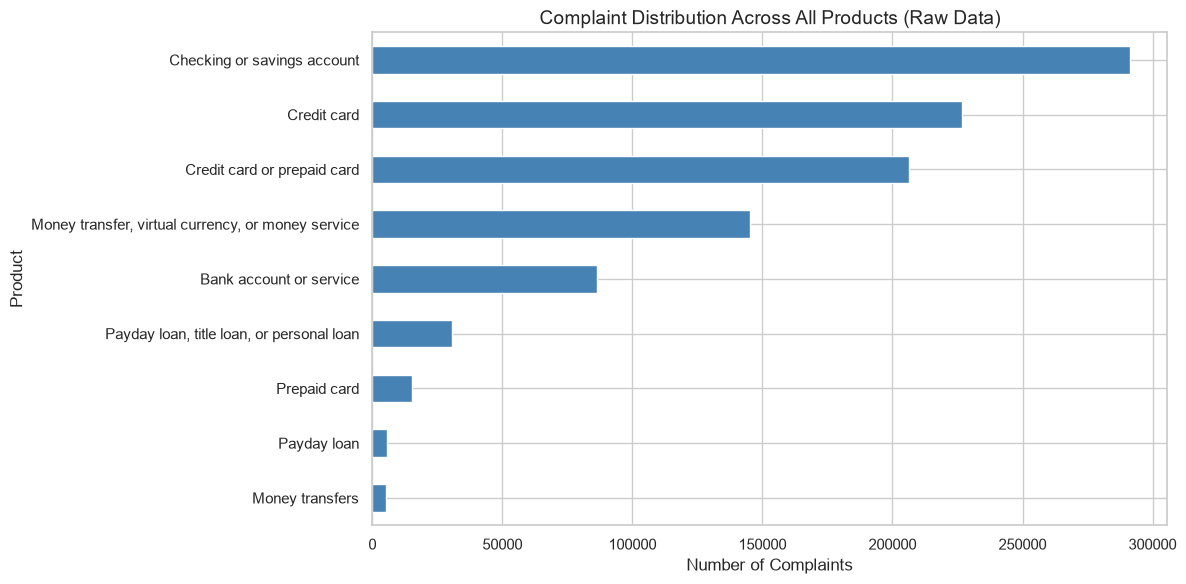

In [14]:
product_counts_raw = df_raw[COL_PRODUCT].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
product_counts_raw.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Complaint Distribution Across All Products (Raw Data)", fontsize=14)
ax.set_xlabel("Number of Complaints")
ax.set_ylabel("Product")
ax.invert_yaxis()
plt.tight_layout()
save_figure("01_raw_product_distribution.png")
plt.show()

## 4. Narrative Availability — With vs Without

Count how many complaints include a consumer narrative versus those that do not.



=== Narrative Availability ===
Consumer complaint narrative
No Narrative     542321
Has Narrative    469999

With narrative   : 469,999  (46.4%)
Without narrative: 542,321  (53.6%)
Figure saved → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\figures\02_narrative_with_without.png


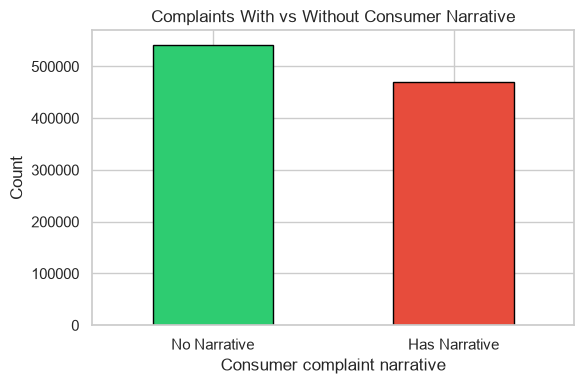

In [15]:
has_narrative = df_raw[COL_NARRATIVE].notna() & df_raw[COL_NARRATIVE].str.strip().ne("")
counts = has_narrative.value_counts().rename({True: "Has Narrative", False: "No Narrative"})

print("=== Narrative Availability ===")
print(counts.to_string())
print(f"\nWith narrative   : {counts.get('Has Narrative', 0):,}  "
      f"({100 * counts.get('Has Narrative', 0) / len(df_raw):.1f}%)")
print(f"Without narrative: {counts.get('No Narrative', 0):,}  "
      f"({100 * counts.get('No Narrative', 0) / len(df_raw):.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_title("Complaints With vs Without Consumer Narrative")
ax.set_ylabel("Count")
ax.set_xticklabels(counts.index, rotation=0)
plt.tight_layout()
save_figure("02_narrative_with_without.png")
plt.show()

## 5. Narrative Word Count Distribution

Analyse the length (in words) of available consumer narratives.



In [16]:
df_with_narrative = df_raw[has_narrative].copy()
df_with_narrative = calculate_word_count(df_with_narrative)

wc = df_with_narrative["narrative_word_count"]
print("=== Narrative Word Count Statistics ===")
print(wc.describe().round(1).to_string())
print(f"\n95th percentile : {wc.quantile(0.95):.0f} words")
print(f"99th percentile : {wc.quantile(0.99):.0f} words")
print(f"Entries < 10 wds: {(wc < 10).sum():,}")
print(f"Entries > 500 wds: {(wc > 500).sum():,}")

=== Narrative Word Count Statistics ===
count    469999.0
mean        205.2
std         225.7
min           1.0
25%          82.0
50%         137.0
75%         255.0
max        6469.0

95th percentile : 586 words
99th percentile : 1049 words
Entries < 10 wds: 2,109
Entries > 500 wds: 33,694


Figure saved → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\figures\03_word_count_histogram.png


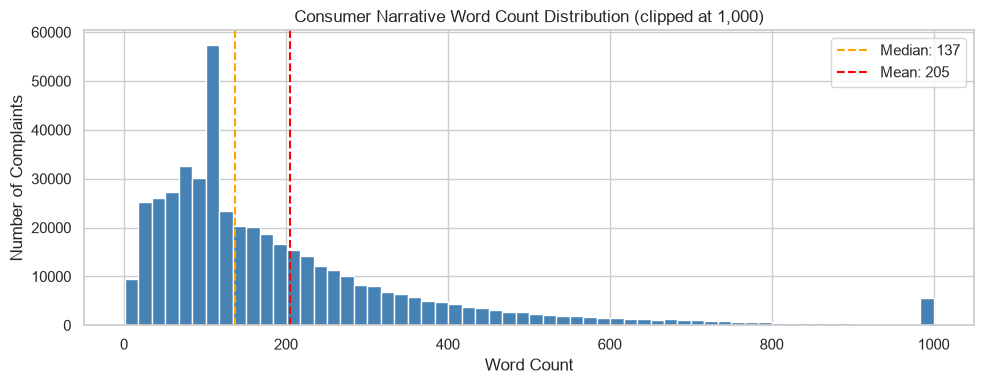

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wc.clip(upper=1000), bins=60, color="steelblue", edgecolor="white")
ax.axvline(wc.median(), color="orange", linestyle="--", label=f"Median: {wc.median():.0f}")
ax.axvline(wc.mean(),   color="red",    linestyle="--", label=f"Mean: {wc.mean():.0f}")
ax.set_title("Consumer Narrative Word Count Distribution (clipped at 1,000)")
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Complaints")
ax.legend()
plt.tight_layout()
save_figure("03_word_count_histogram.png")
plt.show()

## 6. Filter to Four Target Products

Map raw CFPB product strings to the four canonical categories, then drop everything else.



In [18]:
df_mapped = normalize_product(df_raw)

print(f"Rows before product filter : {len(df_mapped):,}")
df_filtered = filter_to_target_products(df_mapped)
print(f"Rows after product filter  : {len(df_filtered):,}")
print(f"Rows removed               : {len(df_mapped) - len(df_filtered):,}")
print()
print("=== Mapped Category Counts ===")
print(df_filtered["product_category"].value_counts().to_string())

Rows before product filter : 1,012,320
Rows after product filter  : 1,012,320
Rows removed               : 0

=== Mapped Category Counts ===
product_category
Credit Card        448335
Savings Account    377383
Money Transfer     150420
Personal Loan       36182


## 7. Filter Empty Narratives

Remove records that have no consumer narrative after product filtering.


In [19]:
print(f"Rows before narrative filter : {len(df_filtered):,}")
df_with_text = filter_empty_narratives(df_filtered)
print(f"Rows after narrative filter  : {len(df_with_text):,}")
print(f"Rows removed                 : {len(df_filtered) - len(df_with_text):,}")

Rows before narrative filter : 1,012,320
Rows after narrative filter  : 469,999
Rows removed                 : 542,321


## 8. Product Distribution After Filtering

Visualise how the four target categories are represented in the filtered dataset.


Figure saved → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\figures\04_filtered_product_distribution.png


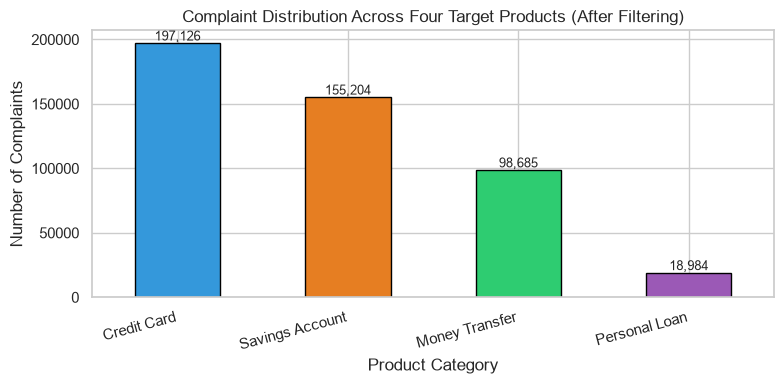

In [20]:
cat_counts = df_with_text["product_category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.plot(kind="bar", ax=ax, color=["#3498db","#e67e22","#2ecc71","#9b59b6"],
                edgecolor="black")
ax.set_title("Complaint Distribution Across Four Target Products (After Filtering)")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Complaints")
ax.set_xticklabels(cat_counts.index, rotation=15, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_figure("04_filtered_product_distribution.png")
plt.show()

## 9. Text Cleaning

Apply the full normalization pipeline: lowercase, boilerplate removal, special character
removal, and whitespace collapsing.


In [21]:
df_with_wc = calculate_word_count(df_with_text)
df_cleaned = clean_narratives(df_with_wc)
df_final = select_output_columns(df_cleaned)

# Show 3 before/after examples
print("=== Cleaning Examples ===\n")
sample_rows = df_with_text.sample(3, random_state=42)
for i, (_, row) in enumerate(sample_rows.iterrows(), 1):
    original = row[COL_NARRATIVE][:300]
    from src.preprocessing import clean_text
    cleaned = clean_text(original)
    print(f"--- Example {i} ---")
    print(f"BEFORE: {original}")
    print(f"AFTER : {cleaned}")
    print()

=== Cleaning Examples ===

--- Example 1 ---
BEFORE: Please, I am XXXX XXXX from XXXX, Firstly, I did Registered to Opened Online Account to that Company Call, XXXX : ( XXXX ) for Some Weeks ago and Again, Created Some Companies Invoices Receipts Retainers to that Company, But that Company had Refused to Processed my Payment Claims Transfer for me to 
AFTER : please, i am redacted redacted from redacted , firstly, i did registered to opened online account to that company call, redacted redacted for some weeks ago and again, created some companies invoices receipts retainers to that company, but that company had refused to processed my payment claims transfer for me to

--- Example 2 ---
BEFORE: My name is XXXX XXXX and once again Im requesting to investigate and locate my refund of {$1400.00}. Refunds of {$700.00} & {$700.00} for order # XXXX I've been dealing with this issue since XXXX last year. 
My bank account when XXXX tried to refund the amount was closed and Wellsfargo after rec

In [22]:
print(f"Final dataset shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")
df_final.head(3)

Final dataset shape: (469999, 9)
Columns: ['complaint_id', 'product_category', 'issue', 'sub_issue', 'company', 'state', 'date_received', 'cleaned_narrative', 'narrative_word_count']


,complaint_id,product_category,issue,sub_issue,company,state,date_received,cleaned_narrative,narrative_word_count
119,14069121,Credit Card,Getting a credit card,Card opened without my consent or knowledge,"CITIBANK, N.A.",TX,2025-06-13,a redacted redacted card was opened under my n...,91
130,14061897,Savings Account,Managing an account,Deposits and withdrawals,WELLS FARGO & COMPANY,ID,2025-06-13,i made the mistake of using my wellsfargo debi...,109
142,14047085,Credit Card,"Other features, terms, or problems",Other problem,"CITIBANK, N.A.",NY,2025-06-12,i have a secured credit card with citibank whi...,156


## 10. Save Filtered Dataset

Save the cleaned, filtered dataset to `data/processed/filtered_complaints.csv`.


In [23]:
save_filtered_dataset(df_final)
print("\nTask 1 complete.")
print(f"Final dataset: {len(df_final):,} rows, {df_final.shape[1]} columns")

✓ Saved filtered dataset → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\filtered_complaints.csv  (469,999 rows)

Task 1 complete.
Final dataset: 469,999 rows, 9 columns
